# Numerical Simulation Laboratory - Notebook 4

In [24]:
import matplotlib
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
from scipy.optimize import curve_fit

## Exercise 04.1

In [25]:
def maxwell_boltzmann(v, T):
    return np.power(2*np.pi*T, -3/2)*4*np.pi*np.power(v,2)*np.exp(-np.power(v,2)/(2*T))

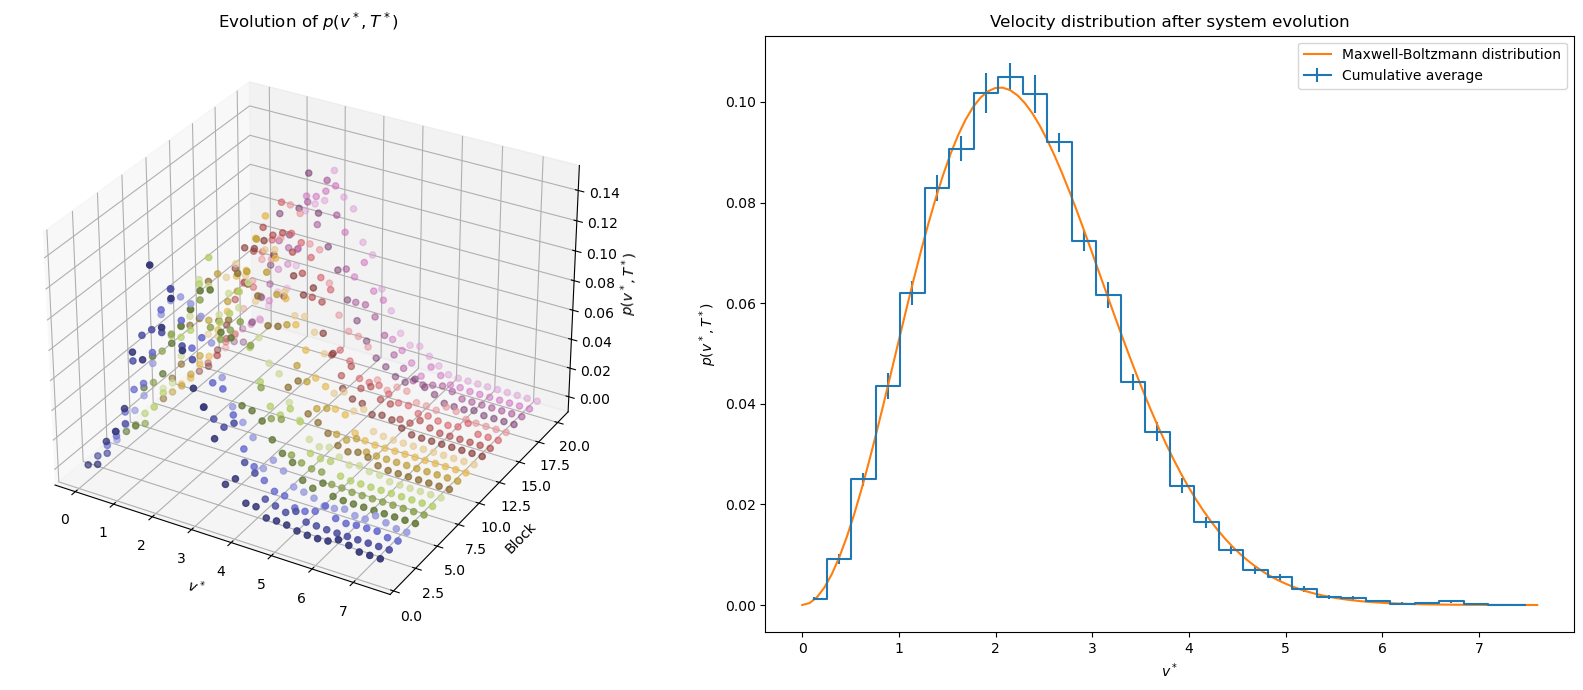

In [26]:
v, pofv, err = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.1/pofv.dat", unpack=True)
data = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.1/pofv_blocks.dat", usecols=(0,1,2))
x = np.linspace(v[0], v[-1]+v[1], 100)
bin_size = v[1]-v[0]
v = v + bin_size / 2.
T = 2.089

fig = plt.figure(figsize=(17, 7))
gs = fig.add_gridspec(1, 2)

ax = fig.add_subplot(gs[1])
ax.errorbar(v, pofv, err, label="Cumulative average", drawstyle="steps-mid")
ax.plot(x, np.power(2*np.pi*T, -3/2)*4*np.pi*np.power(x,2)*np.exp(-np.power(x,2)/(2*T))*bin_size, label="Maxwell-Boltzmann distribution")
ax.set_title("Velocity distribution after system evolution")
ax.set_xlabel("$v^*$")
ax.set_ylabel("$p(v^*,T^*)$")
ax.legend()

ax = fig.add_subplot(gs[0], projection="3d")
sc = ax.scatter(data[:,1], data[:,0], data[:,2], c=data[:,0], cmap='tab20b')
ax.set_title("Evolution of $p(v^*,T^*)$")
ax.set_xlabel("$v^*$")
ax.set_ylabel("Block")
ax.set_zlabel("$p(v^*,T^*)$", rotation=90, horizontalalignment='center', verticalalignment='baseline')

fig.tight_layout()
plt.show()

To test the function that calculates $p(v^*,T^*)$ a simulation was run with $T^*=1.9$ ($T_\text{eff}=2.089\pm0.004$), $\rho^*=0.05$, $r_c=5.0$, $N_\text{blocks}=20$ and $N_\text{steps}=2000$. The calculation of the probability distribution function is correct since the result is resembles the Maxwell-Boltzmann distribution. The discrepancies can be explained by the fact that the system was not equilibrated so that the evolution of $p(v^*,T^*)$ could be shown.

## Esercizio 04.2

Measured temperature: 1.340 +- 0.012
Fit temperature: 1.365


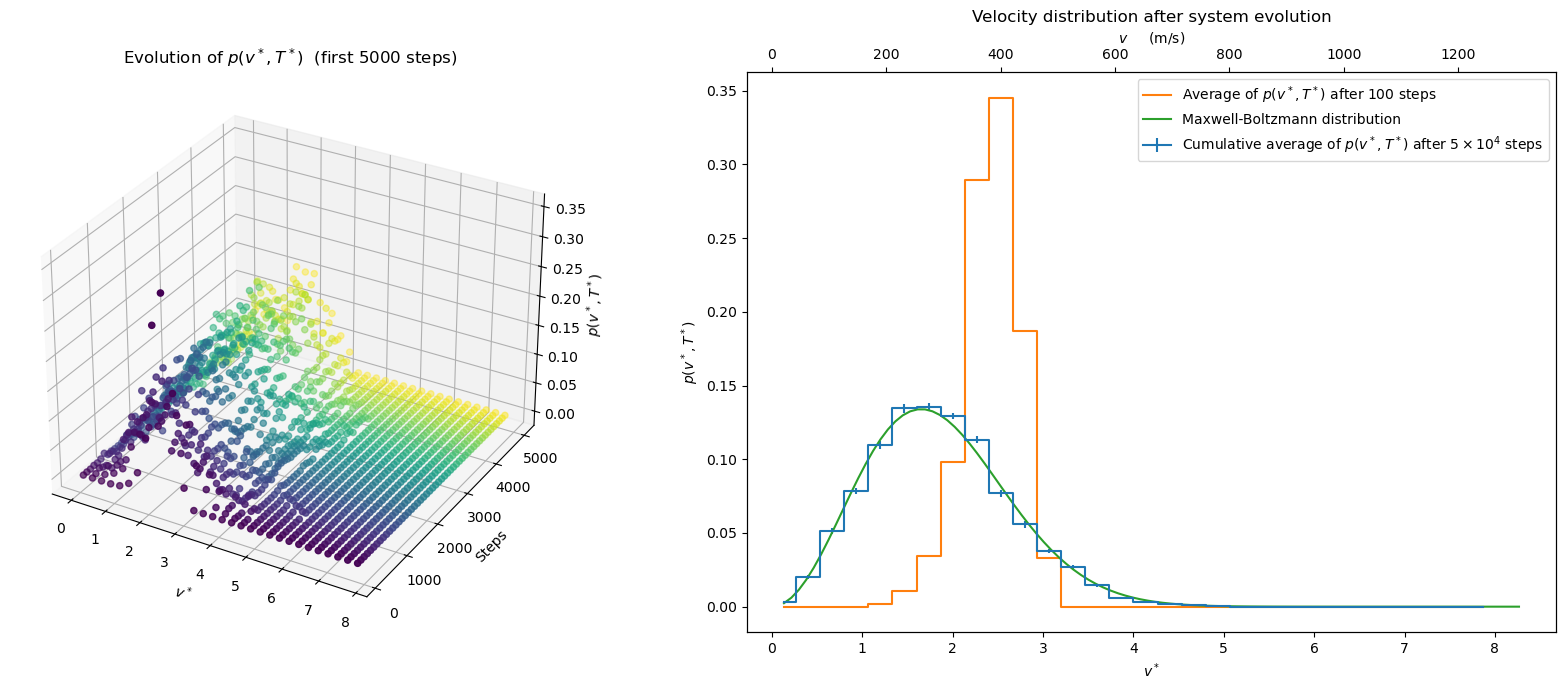

In [27]:
sigma = 0.34
epsilon = 120 * 1.380649e-23
m = 39.948 * 1.660539e-27

v, pofv, err = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.2_2/pofv.dat", unpack=True)
data = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.2_1/pofv_blocks.dat")
temp_block, temp_avg, t_err = np.loadtxt("../NSL_SIMULATOR/OUTPUT_04.2_2/temperature.dat", usecols=(1,2,3), unpack=True)
nbins = v.size
bin_size = v[1] - v[0]
v += bin_size / 2.

# Fit of the Maxwell-Boltzmann distribution
x = np.linspace(v[0], v[-1]+v[1], 100)
popt, pcov = curve_fit(maxwell_boltzmann, v, pofv/bin_size)
T = popt[0]
print(f"Measured temperature: {temp_avg[-1]:.3f} +- {t_err[-1]:.3f}")
print(f"Fit temperature: {T:.3f}")

fig = plt.figure(figsize=(17, 7))
gs = fig.add_gridspec(1, 2)

ax = fig.add_subplot(gs[1])
ax.errorbar(v, pofv, yerr=err, label="Cumulative average of $p(v^*,T^*)$ after $5\\times10^4$ steps", drawstyle="steps-mid")
ax.plot(v, data[:v.size,2], drawstyle="steps-mid", label="Average of $p(v^*,T^*)$ after $100$ steps")
ax.plot(x, np.power(2*np.pi*T, -3/2)*4*np.pi*np.power(x,2)*np.exp(-np.power(x,2)/(2*T))*bin_size, label="Maxwell-Boltzmann distribution")
ax.set_title("Velocity distribution after system evolution")
ax.set_xlabel("$v^*$")
ax.set_ylabel("$p(v^*,T^*)$")
ax.legend()
ax2 = ax.twiny()
ax2.set_xlim(np.array(ax.get_xlim())*np.sqrt(epsilon/m))
ax2.set_xlabel("$v$     (m/s)")

ax = fig.add_subplot(gs[0], projection="3d")
sc = ax.scatter(data[:,1], 100*data[:,0], data[:,2], c=data[:,0], cmap='viridis')
ax.set_title("Evolution of $p(v^*,T^*)$  (first $5000$ steps)")
ax.set_xlabel("$v^*$")
ax.set_ylabel("Steps")
ax.set_zlabel("$p(v^*,T^*)$", rotation=90, horizontalalignment='center', verticalalignment='baseline')

fig.tight_layout()
plt.show()

The above figure shows the convergence of the velocity probability distribution function to the Maxwell-Boltzmann distribution when starting from a low entropy configuration. To have the initial position of all the particles occupy only half of the simulation box the code was temporary changed: when loading the positions from the configuration file the program multiplies the position with the `_halfside` rather than the `_side` variable. The starting velocity distribution is a Dirac delta centered in $v_{T^*}=\sqrt{3T^*}$.

The 3D graph of the evolution of $p(v^*,T^*)$ shows that the first block's probability distribution is close to a Dirac delta, and after that the function quickly converges to the Maxwell-Boltzmann distribution. This means that the system is converging to a more homogenous configuration, i.e. a configuration with higher entropy. By changing the direction of time the system could return to the initial high entropy configuration as long as the numerical errors don't change the backwards trajectory: any deviation from the forward time evolution would bring the system on a new trajectory in the phase space, that cannot converge to the initial configuration since it is an extremely unlikely configuration having a very low entropy.

By fitting the Maxwell-Boltzmann distribution to the block average of the velocity distribution we find a $T_\text{fit}=1.365$, which is distant about $2\sigma$ to the measured temperature $T_\text{avg}=1.340\pm0.012$. This is shows that the Maxwell-Boltzmann distribution is the right fit for the final $p(v^*,T^*)$.

## Esercizio 4.3

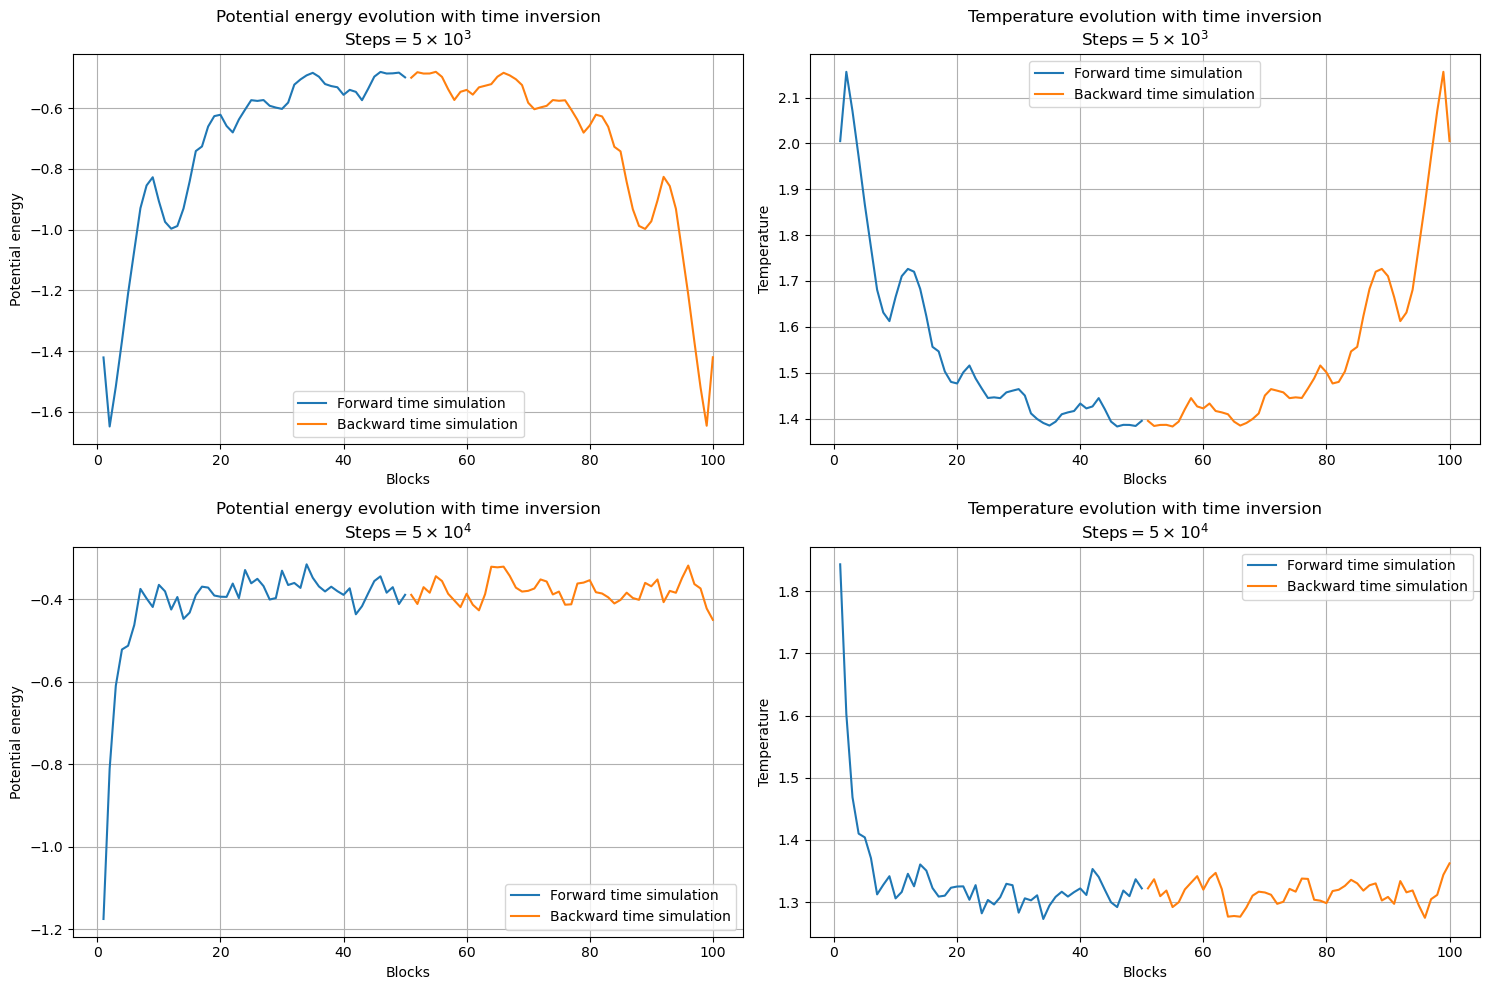

In [28]:
fig, axs = plt.subplots(2, 2, figsize=(15,10))
sym_lengths = [r"5\times10^3", r"5\times10^4"]

for i in range(2):
    blocks, pe = np.loadtxt(f"../NSL_SIMULATOR/OUTPUT_04.2_{i+1}/potential_energy.dat", usecols=(0,1),unpack=True)
    temp = np.loadtxt(f"../NSL_SIMULATOR/OUTPUT_04.2_{i+1}/temperature.dat", usecols=1)

    pe_inverse = np.loadtxt(f"../NSL_SIMULATOR/OUTPUT_04.3_{i+1}/potential_energy.dat", usecols=1)
    temp_inverse = np.loadtxt(f"../NSL_SIMULATOR/OUTPUT_04.3_{i+1}/temperature.dat", usecols=1)

    axs[i,0].plot(blocks, pe, label="Forward time simulation")
    axs[i,0].plot(blocks+blocks.size, pe_inverse, label="Backward time simulation")
    axs[i,0].set_xlabel("Blocks")
    axs[i,0].set_ylabel("Potential energy")
    axs[i,0].set_title(f"Potential energy evolution with time inversion\n$\\text{{Steps}}={sym_lengths[i]}$")

    axs[i,1].plot(blocks, temp, label="Forward time simulation")
    axs[i,1].plot(blocks+blocks.size, temp_inverse, label="Backward time simulation")
    axs[i,1].set_xlabel("Blocks")
    axs[i,1].set_ylabel("Temperature")
    axs[i,1].set_title(f"Temperature evolution with time inversion\n$\\text{{Steps}}={sym_lengths[i]}$")
    for j in range(2):
        axs[i,j].legend()
        axs[i,j].grid()
plt.tight_layout()

By plotting the average in each block of the potential energy and the temperature we can see whether by inverting the direction of time the system follows the same path to the low entropic initial condition or it converges to another state. When executing the experiment with $5\times10^3$ time steps the block averages of the measured quantities are exactly equal in the forward and backward simulation: this means that the system is able to return to the low entropic initial state. When the number of steps is increased to $5\times10^4$ the inverted time simulation doesn't return to the initial state but converges to an equilibrium state similar to the final state of the forward time simulation. The difference in behavior is explained by the fact that the shorter simulation hasn't yet reached an equilibrium configuration, so the Verlet integration algorithm, which is time reversible, is able to return to the initial condition. When the equilibration is completed in the longer simulation the integration algorithm can't return to the initial condition because it has accumulated too many numerical errors, which make the inverse simulation deviate from the path leading to the low entropic configuration.